### EDA - India Air Quality Dataset

Full exploratory analysis of 435,000+ rows across Indian cities.
Covers null patterns, city rankings, state comparisons,
and PM2.5 distribution across India.

Key finding: PM2.5 is missing 97.86% nationally.
Delhi is the most polluted city and state by a large margin.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data.csv", encoding="cp1252")
df.head()

C:\Users\Riddhi Kale\AppData\Local\Temp\ipykernel_7756\3853325627.py:1: DtypeWarning: Columns (0: stn_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data.csv", encoding="cp1252")


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [4]:
df.shape

(435742, 13)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  str    
 2   state                        435742 non-null  str    
 3   location                     435739 non-null  str    
 4   agency                       286261 non-null  str    
 5   type                         430349 non-null  str    
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  str    
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  str    
dtypes: float64

In [5]:
nulls = df.isnull().sum()
nulls

stn_code                       144077
sampling_date                       3
state                               0
location                            3
agency                         149481
type                             5393
so2                             34646
no2                             16233
rspm                            40222
spm                            237387
location_monitoring_station     27491
pm2_5                          426428
date                                7
dtype: int64

In [16]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
stn_code,291665.0,803.0,193.0,1428.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sampling_date,435739,5485,19-03-15,253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,435742,37,Maharashtra,60384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,435739,304,Guwahati,9984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agency,286261,64,Maharashtra State Pollution Control Board,27857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,430349,10,"Residential, Rural and other Areas",179014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
so2,401096.0,NaN,NaN,NaN,10.829414,11.177187,0.0,5.0,8.0,13.7,909.0
no2,419509.0,NaN,NaN,NaN,25.809623,18.503086,0.0,14.0,22.0,32.2,876.0
rspm,395520.0,NaN,NaN,NaN,108.832784,74.87243,0.0,56.0,90.0,142.0,6307.033333
spm,198355.0,NaN,NaN,NaN,220.78348,151.395457,0.0,111.0,187.0,296.0,3380.0


In [6]:
null_pct = (nulls / len(df) * 100).round(2)
null_pct

stn_code                       33.06
sampling_date                   0.00
state                           0.00
location                        0.00
agency                         34.30
type                            1.24
so2                             7.95
no2                             3.73
rspm                            9.23
spm                            54.48
location_monitoring_station     6.31
pm2_5                          97.86
date                            0.00
dtype: float64

In [7]:
print(pd.DataFrame({"missing": nulls, "percent": null_pct}))

                             missing  percent
stn_code                      144077    33.06
sampling_date                      3     0.00
state                              0     0.00
location                           3     0.00
agency                        149481    34.30
type                            5393     1.24
so2                            34646     7.95
no2                            16233     3.73
rspm                           40222     9.23
spm                           237387    54.48
location_monitoring_station    27491     6.31
pm2_5                         426428    97.86
date                               7     0.00


### Null pattern finding

pm2_5 is missing 97.86% of the time across India.
This means most Indian cities simply did not have PM2.5 sensors when this data was collected. It is not a mistake in the data — it is a gap in monitoring infrastructure.

Delhi is one of the very few cities with PM2.5 readings, which is why we focused on Delhi all week.

spm is missing 54% — it is an older pollution measure that was being replaced by pm2_5 over time.

so2 and rspm are only missing 7–9% — much more usable.

For the Health Risk Scorer: I cannot use pm2_5 as a feature for all of India — there is not enough data.
rspm (PM10) is the better choice for a national model.

In [8]:
so2_nulls = df.groupby("location")["so2"].apply(
    lambda x: x.isnull().sum()
).sort_values(ascending=False)

In [9]:
print("Cities with most SO2 missing values:")
print(so2_nulls.head(10))

Cities with most SO2 missing values:
location
Chandigarh      4101
Paonta Sahib    1303
Bhubaneshwar    1278
Agra            1216
Nahan           1038
Kochi            997
Aizawl           974
Baddi            884
Dimapur          871
Kozhikode        858
Name: so2, dtype: int64


In [10]:
print(f"\nCities with zero SO2 nulls: {(so2_nulls == 0).sum()}")


Cities with zero SO2 nulls: 92


In [11]:
city_pm25 = df.groupby("location")["pm2_5"].mean()
city_pm25 = city_pm25.dropna().sort_values(ascending=False)
city_pm25.head()

location
Delhi          95.113208
Talcher        82.394231
Bhopal         79.100000
Gwalior        77.187417
Barrackpore    75.750000
Name: pm2_5, dtype: float64

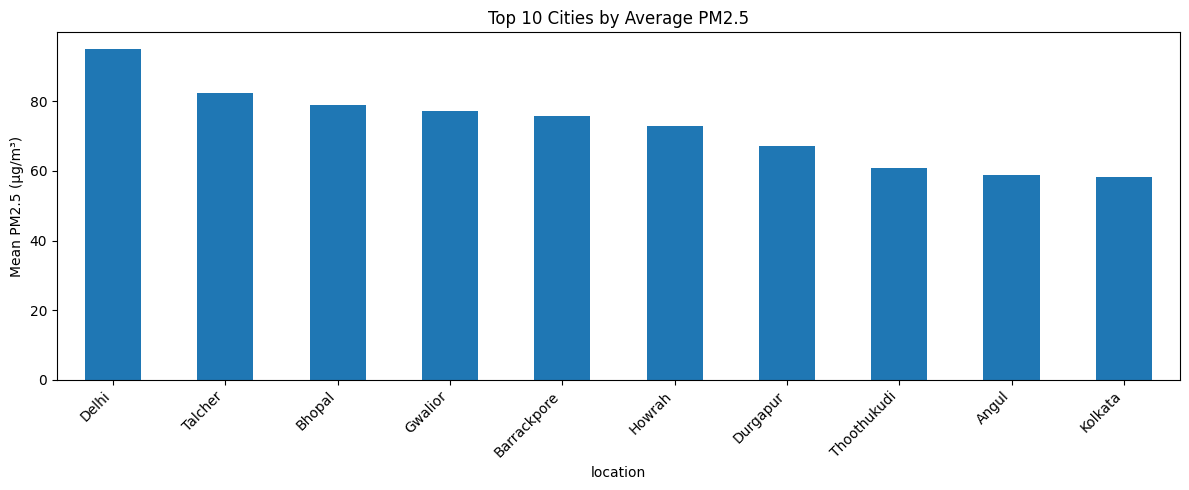

In [12]:
city_pm25.head(10).plot(kind="bar", figsize=(12, 5))
plt.title("Top 10 Cities by Average PM2.5")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("worst_cities_pm25.png", dpi=150)
plt.show()

In [13]:
state_pm25 = df.groupby("state")["pm2_5"].mean()
state_pm25 = state_pm25.dropna().sort_values(ascending=False)
print(state_pm25)

state
Delhi                   95.113208
Madhya Pradesh          65.064565
West Bengal             64.890625
Telangana               43.968927
Odisha                  42.204089
Gujarat                 30.729696
Dadra & Nagar Haveli    30.511628
Tamil Nadu              29.550441
Daman & Diu             27.886364
Goa                     18.855612
Name: pm2_5, dtype: float64


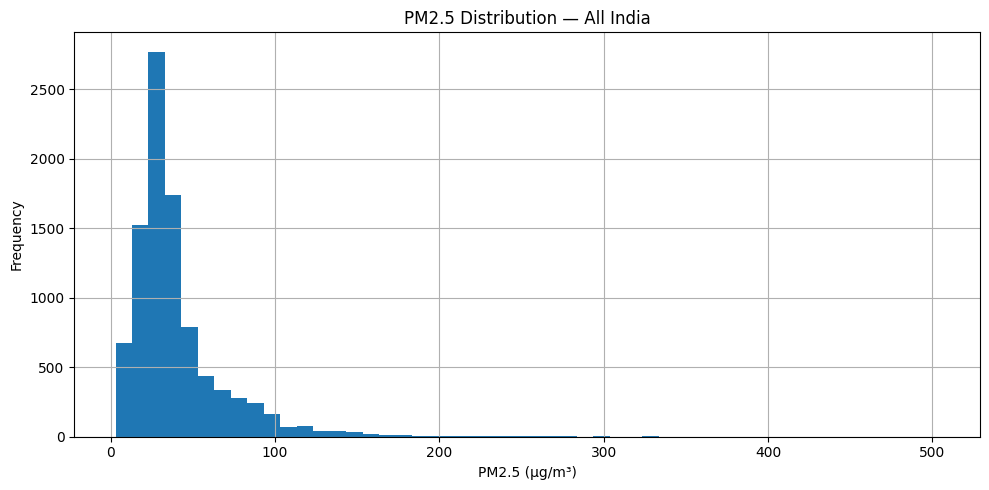

In [14]:
plt.figure(figsize=(10, 5))
df["pm2_5"].dropna().hist(bins=50)
plt.title("PM2.5 Distribution — All India")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("pm25_distribution_india.png", dpi=150)
plt.show()

### KEY FINDINGS

1. Delhi has the highest average PM2.5 (95.11 µg/m³) of all cities in this dataset — more than 6 times the WHO safe limit of 15 µg/m³.

2. PM2.5 is missing for 97.86% of the dataset nationally.
Most Indian cities did not have PM2.5 sensors during this period. Delhi, Talcher, Bhopal, Gwalior and Barrackpore are among the very few cities with consistent readings.

3. Delhi state has the worst average PM2.5 nationally (95.11), nearly 1.5x higher than second-place Madhya Pradesh (65.06).
The gap is large - Delhi is in a category of its own.

4. Southern states (Tamil Nadu, Goa) have significantly cleaner air than northern states (Delhi, Madhya Pradesh, West Bengal).
Geography, crop burning, and industrial density drive this gap.

5. Bhopal appears in both the worst cities list (rank 3) and had the highest PM2.5 volatility in Day 2 (std dev 64.46) -
but its average (79.10) is lower than Delhi's (95.11).
Bhopal has extreme spike days. Delhi is consistently bad.